<a href="https://colab.research.google.com/github/Saulo-Azevedo/TCC_POS_PUC/blob/main/TCC_Detector_de_spam_em_email.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de SMS Spam: Detectando Mensagens Não Desejadas.


## 1.  Introução

Os dados utilizados neste estudo foram coletados a partir do conjunto de dados SMS Spam Collection Dataset disponível no site Kaggle.
Esse conjunto de dados consiste em uma coleção de mensagens de texto em inglês, classificadas como spam ou não-spam, e foi coletado para fins de pesquisa em detecção de spam em mensagens de texto.
O objetivo deste estudo foi identificar mensagens de spam ou não-spam em uma lista de e-mails, utilizando o conjunto de dados mencionado. Vale ressaltar que os dados foram obtidos da última vez que a informação foi atualizada até janeiro de 2022, e o link específico para o conjunto de dados pode ser acessado diretamente na fonte original no site Kaggle.

## 2.  Descrição do Problema e da Solução Proposta:

O objetivo principal deste notebook é desenvolver um modelo preditivo que classifique com precisão as mensagens SMS recebidas como "ham" (legítimas) ou "spam". Utilizaremos o conjunto de dados da Coleção de Spam em Mensagens de SMS, que contém 5.574 mensagens SMS rotuladas com suas respectivas categorias.




## 3. Coleta e verificação dos dados a serem utilizados na analise:

Os dados utilizados neste estudo foram coletados a partir do conjunto de dados SMS Spam Collection Dataset disponível no site Kaggle.
Esse conjunto de dados consiste em uma coleção de mensagens de texto em inglês, classificadas como spam ou não-spam, e foi coletado para fins de pesquisa em detecção de spam em mensagens de texto.
O conjunto inclui várias subcoleções de mensagens, cada uma proveniente de fontes distintas.

**Data e Link de Aquisição:**

Os dados foram obtidos ertre Dezembro de 2023 a Janeiro de 2024,a última vez que a informação foi atualizada foi janeiro de 2022, esse é link específico para o conjunto de dados disponível neste contexto (https://archive.ics.uci.edu/dataset/228/sms+spam+collection).

**Formato e Estrutura do Dataset:**

O conjunto de dados está estruturado em arquivos de texto, com uma mensagem por linha. Cada linha possui duas colunas: a primeira (v1) contém a etiqueta da mensagem (ham ou spam), e a segunda (v2) contém o texto bruto da mensagem.
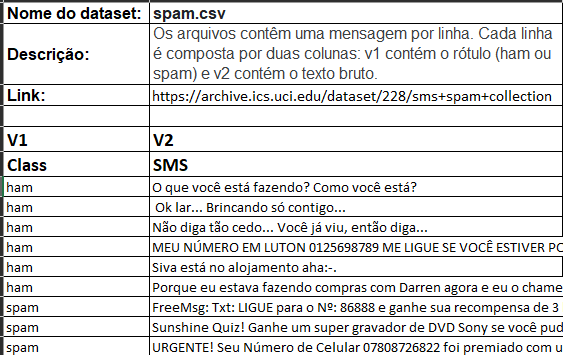

**Relacionamento entre Datasets:**

Os diferentes conjuntos de dados (Grumbletext, NSC, Caroline Tag's Thesis, SMS Spam Corpus v.0.1 Big) foram combinados para formar o conjunto abrangente utilizado para a pesquisa sobre spam em mensagens de SMS.



A seguir, são apresentados os detalhes de cada fonte de dados:

*   Grumbletext Web Site: Contém 425 mensagens de spam de SMS extraídas manualmente do site, que é um fórum do Reino Unido onde usuários de telefones celulares compartilham reclamações sobre mensagens de spam em SMS
http://www.grumbletext.co.uk/

*   NUS SMS Corpus (NSC): Consiste em um subconjunto de 3.375 mensagens legítimas (ham) escolhidas aleatoriamente de um corpus maior, composto por cerca de 10.000 mensagens legítimas coletadas para pesquisa no Departamento de Ciência da Computação da Universidade Nacional de Singapura.
http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/

*  Caroline Tag's PhD Thesis: Fornece uma lista adicional de 450 mensagens legítimas (ham) coletadas da tese de doutorado de Caroline Tag.
http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf

*	SMS Spam Corpus v.0.1 Big: Por fim, o conjunto de dados incorpora o SMS Spam Corpus v.0.1 Big, que contém 1.002 mensagens legítimas (ham) e 322 mensagens de spam. Esse corpus está disponível publicamente.
http://www.esp.uem.es/jmgomez/smsspamcorpus/




## 3.1 Importando bibliotecas a serem utilizadas:

In [ ]:
# Importação de Bibliotecas Necessárias
import numpy as np # Para operações numéricas
import pandas as pd # Para manipulação e análise de dados
import matplotlib.pyplot as plt # Para visualização de dados
%matplotlib inline

#Importação do WordCloud para visualização de texto
from wordcloud import WordCloud

# Importação do NLTK para processamento de linguagem natural
import nltk
from nltk.corpus import stopwords # Para palavras irrelevantes (stopwords)

# Download dos dados do NLTK
nltk.download('stopwords') # Download dos dados de stopwords
nltk.download('punkt') # Download dos dados do tokenizador

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## 3.1 Lendo o arquivo CSV que contém os dados:


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tcc PUC/spam.csv', encoding='latin1')
#atualizar link de dowload no tcc

In [ ]:
#retirar esse trecho do código final ( averiguar se fica bom)
styled_df = df.head()
styled_df = styled_df.style.set_table_styles([
    {"selector": "th", "props": [("color", 'black'), ("background-color", "#FF00CC")]}
])
styled_df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",nan,nan,nan
1,ham,Ok lar... Joking wif u oni...,nan,nan,nan
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,nan,nan,nan
3,ham,U dun say so early hor... U c already then say...,nan,nan,nan
4,ham,"Nah I don't think he goes to usf, he lives around here though",nan,nan,nan


# 4. Processamento/Tratamento de Dados



## 4.1 | Exibindo informações do Data Frame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## 4.2 |Removendo Colunas

In [ ]:
# Removendo as colunas com rótulos “Unnamed: 2”, “Unnamed: 3” e “Unnamed: 4”
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [ ]:
styled_df = df.head(5).style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])

## 4.3 | Renomeando colunas

In [ ]:
 # Usando metodo .rename() para renomear colunas do DataFrame df
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)

## 4.4 | Convertendo os rótulos da coluna “target”

In [ ]:
#  Convertendo os rótulos da coluna “target” em valores numéricos
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
styled_df = df.head().style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])

,target,text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives around here though"


## 4.5 | Verificação de Valores Ausentes

In [ ]:
# Usando metodo .isnull() para verificar valores ausentes
df.isnull().sum()

target    0
text      0
dtype: int64

## 4.6 | Verificando valores duplicados

In [ ]:
# Usando metodo .duplicate() para checar valores duplicados
df.duplicated().sum()

403

## 4.7 |Removendo valores duplicados

In [ ]:
# Usando metodo .drop_duplicates() para remover valores duplicados
df = df.drop_duplicates(keep = 'first')

## 4.8 | Checando formato do Dataset

In [ ]:
# Usando metodo .shape() para identificar os dados em termos de número de linhas e colunas
df.shape

# 5. EDA

5.1 | Percentage of Ham and Spam

In [ ]:
values = df['target'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('percentage of 0 :' ,percentage_0)
print('percentage of 1 :' ,percentage_1)

percentage of 0 : 87.3669955503966
percentage of 1 : 12.633004449603405


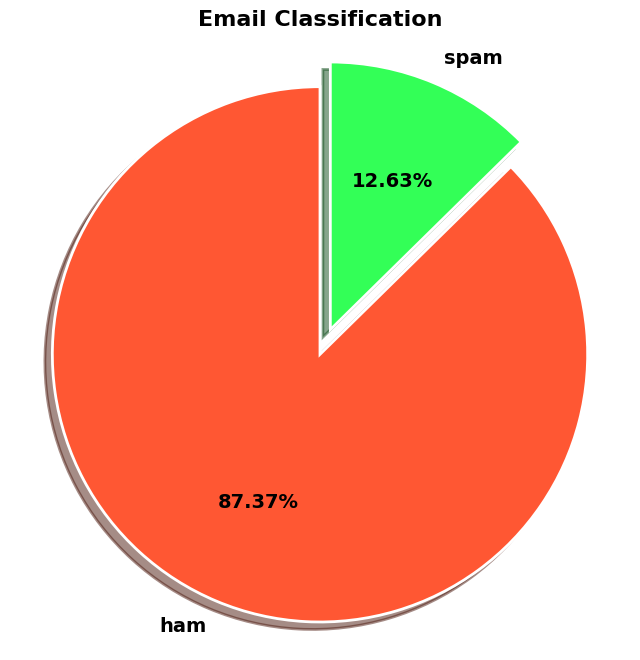

In [ ]:
import matplotlib.pyplot as plt

# Sample data
# values = [75, 25]  # Example values for 'ham' and 'spam'

# Define custom colors
colors = ['#FF5733', '#33FF57']

# Define the explode parameter to create a gap between slices
explode = (0, 0.1)  # Explode the second slice (spam) by 10%

# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

# Create the pie chart with custom colors, labels, explode parameter, and shadow
wedges, texts, autotexts = ax.pie(
    values, labels=['ham', 'spam'],
    autopct='%0.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    explode=explode,  # Apply the explode parameter
    shadow=True  # Add shadow
)

# Customize text properties
for text, autotext in zip(texts, autotexts):
    text.set(size=14, weight='bold')
    autotext.set(size=14, weight='bold')

# Add a title
ax.set_title('Email Classification', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Show the pie chart
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_waterfall(data, labels):
    """
    Create a waterfall chart using Matplotlib.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Create the waterfall plot
    ax.bar(labels, data, color=['#1f78b4' if d < 0 else '#33a02c' for d in data], align='center')

    # Add the cumulative sum for each bar
    total = 0
    for i, value in enumerate(data):
        total += value
        ax.text(i, total, f"{total:.2f}", ha='center', va='bottom', fontweight='bold')

    # Customize labels and title
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Value')
    ax.set_title('Waterfall Chart')

    # Show the plot
    plt.show()

# Sample data
values = [75, -25]  # Example values for 'ham' and 'spam'
labels = ['ham', 'spam']

# Create the waterfall chart
plot_waterfall(values, labels)

5.2 | Text Length and Structure Analysis

In [ ]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


5.3 | Summary Statistics for Legitimate Messages

In [ ]:
#ham
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


5.4 | Summary Statistics for Spam Messages

In [ ]:
#spam
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


5.5 | Character Length Distribution for Legitimate and Spam Messages

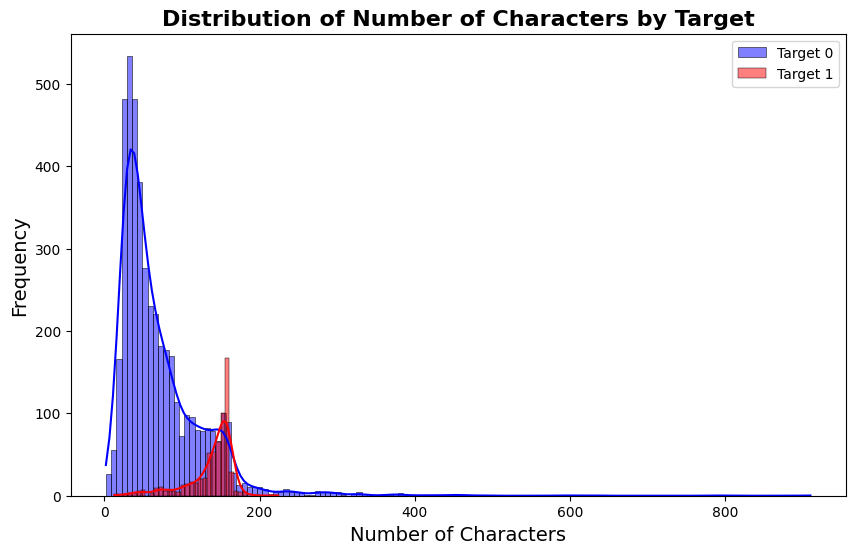

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Characters by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()

5.6 | Word Count Distribution for Legitimate and Spam Messages

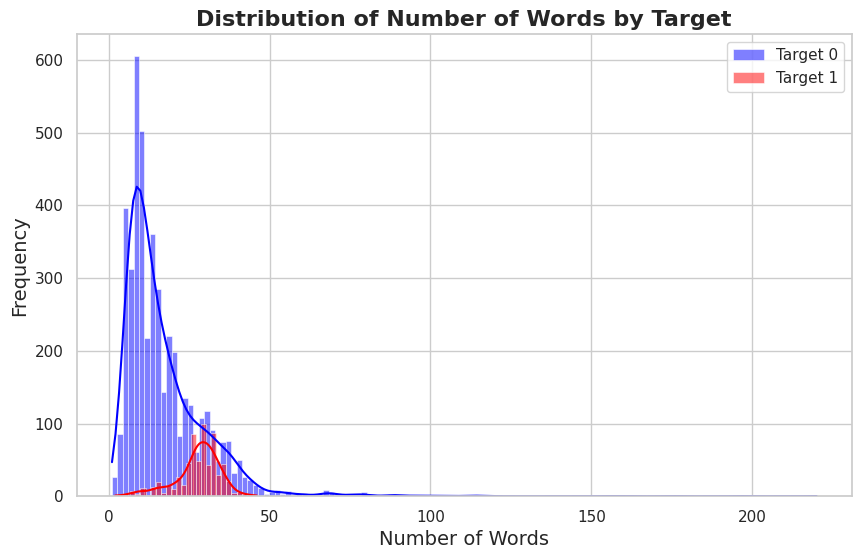

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()

5.7 | Pairplot for Data Visualization

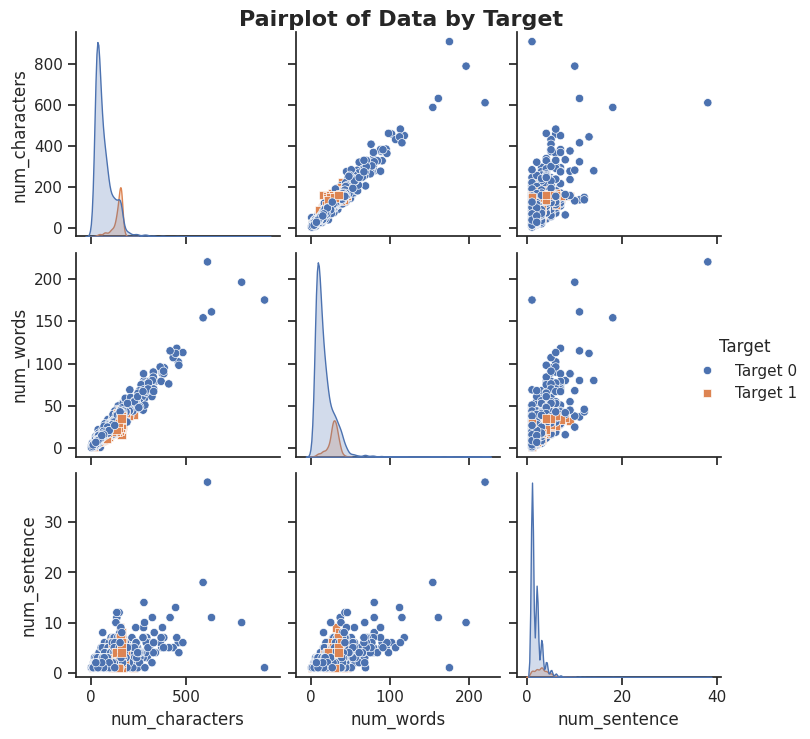

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot with custom styling
sns.set(style='ticks', color_codes=True)
g = sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s"])

# Set a title for the pairplot
g.fig.suptitle("Pairplot of Data by Target", fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)  # Adjust the position of the title

# Customize the legend
g._legend.set_title('Target')
for t, l in zip(g._legend.texts, ["Target 0", "Target 1"]):
    t.set_text(l)

# Show the pairplot
plt.show()

5.8 | Coorelation

In [ ]:
df[['target','num_characters', 'num_words', 'num_sentence']].corr()

,target,num_characters,num_words,num_sentence
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


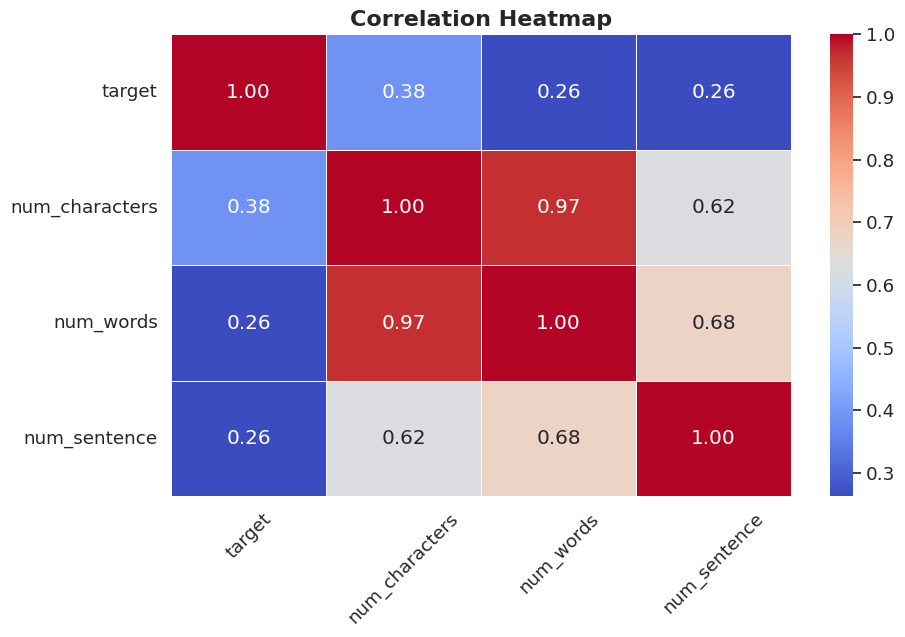

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns for the correlation matrix
correlation_matrix = df[['target', 'num_characters', 'num_words', 'num_sentence']].corr()

# Create a heatmap with custom styling
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)  # Adjust font scale for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

# Set a title for the heatmap
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the heatmap
plt.show()


# 6. Data Preprocessing

In [ ]:
# Importing the Porter Stemmer for text stemming
from nltk.stem.porter import PorterStemmer

# Importing the string module for handling special characters
import string

# Creating an instance of the Porter Stemmer
ps = PorterStemmer()

# Lowercase transformation and text preprocessing function
def transform_text(text):
    # Transform the text to lowercase
    text = text.lower()

    # Tokenization using NLTK
    text = nltk.word_tokenize(text)

    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    # Removing stop words and punctuation
    text = y[:]
    y.clear()

    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    # Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

    # Join the processed tokens back into a single string
    return " ".join(y)

In [ ]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

6.1 | Creating a New Column: 'transformed_text'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
styled_df = df.head(5).style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2,go jurong point crazi avail bugi n great world la e buffet cine got amor wat
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2,free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1,nah think goe usf live around though


6.2 | Word Cloud for Spam Messages

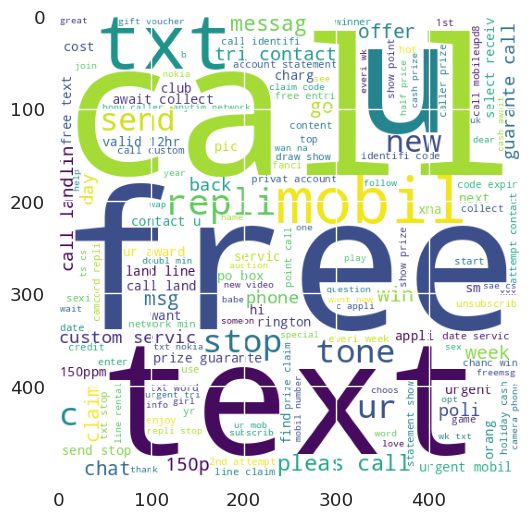

In [ ]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

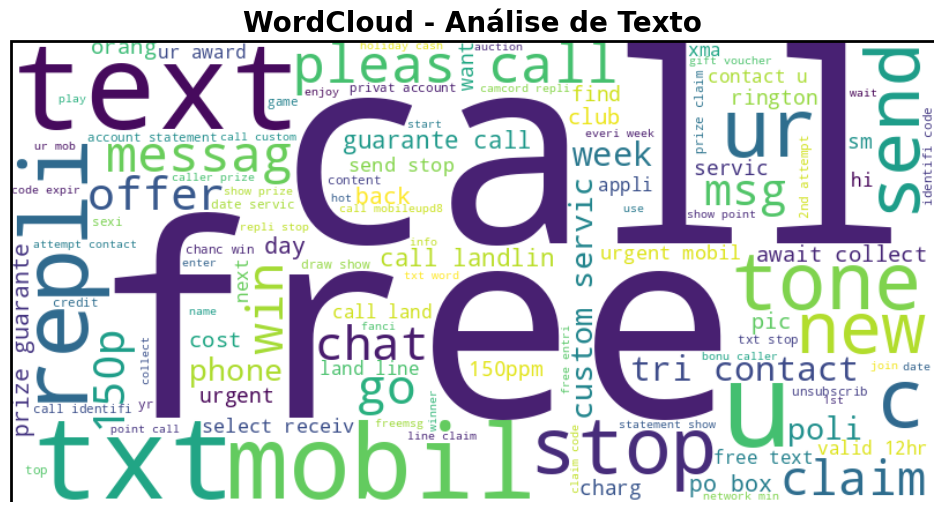

In [ ]:
#analisar usar esse código
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Configuração da WordCloud
wc = WordCloud(width=800, height=400, min_font_size=10, background_color='white', colormap='viridis', random_state=42)

# Criar a nuvem de palavras para a categoria 'spam'
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

# Personalizar a aparência
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis("off")

# Adicionar um título profissional
plt.title("WordCloud - Análise de Texto", fontsize=20, color='black', fontweight='bold')

# Adicionar uma borda ao redor da nuvem de palavras
plt.gca().add_patch(plt.Rectangle((0, 0), 800, 400, linewidth=2, edgecolor='black', facecolor='none'))

# Adicionar uma grade para uma aparência mais profissional
plt.grid(False)

# Mostrar a nuvem de palavras
plt.show()


6.2 | Word Cloud for Not spam Messages

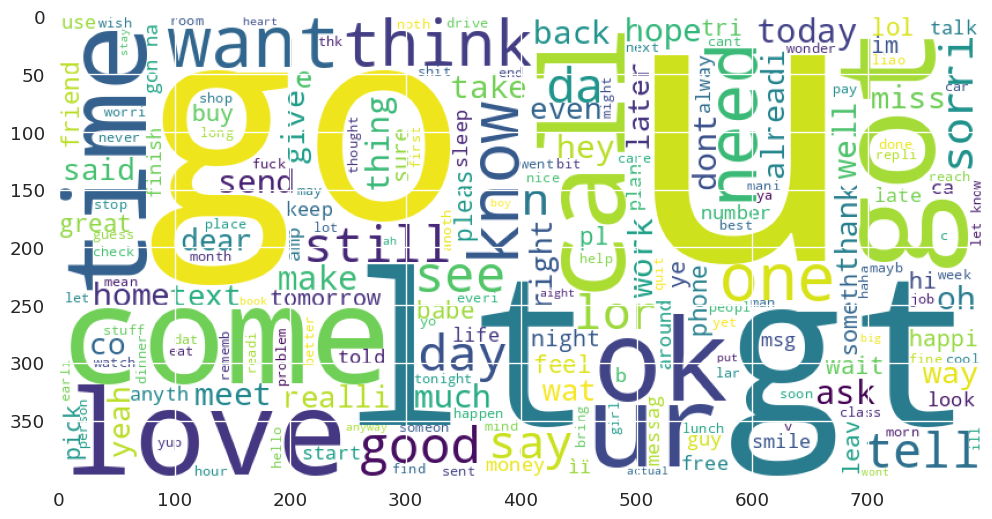

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)
plt.show()

6.3 | Find top 30 words of spam

In [ ]:
spam_carpos = []
for sentence in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentence.split():
        spam_carpos.append(word)

In [ ]:
from collections import Counter
filter_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

<ipython-input-58-b4964bcadea0>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')


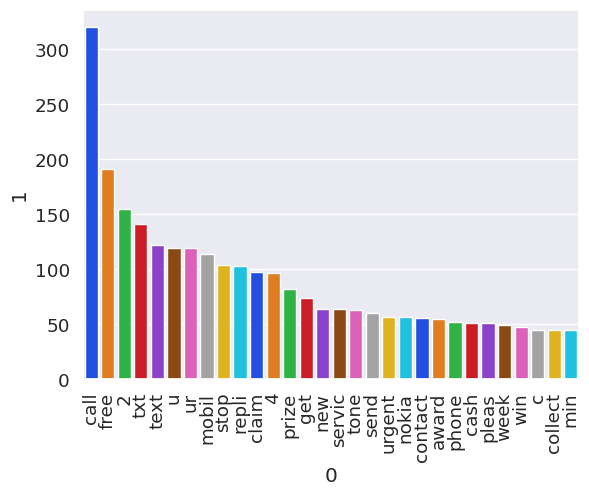

In [ ]:
sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')
plt.xticks(rotation = 90)
plt.show()

<ipython-input-59-6620b99aa8b5>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filter_df, x=filter_df[0], y=filter_df[1], palette='Set2')


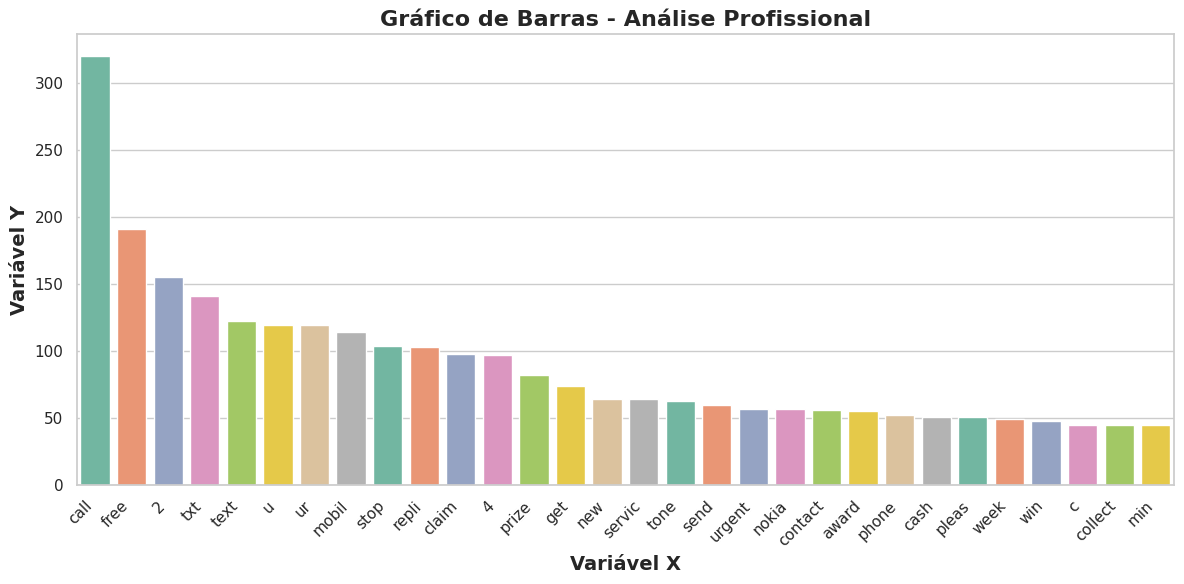

In [ ]:
#analisar manter esse código
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração do estilo para uma aparência profissional
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criar o gráfico de barras
sns.barplot(data=filter_df, x=filter_df[0], y=filter_df[1], palette='Set2')

# Adicionar rótulos e título
plt.xlabel("Variável X", fontsize=14, fontweight='bold')
plt.ylabel("Variável Y", fontsize=14, fontweight='bold')
plt.title("Gráfico de Barras - Análise Profissional", fontsize=16, fontweight='bold')

# Rotacionar os rótulos no eixo x para melhor legibilidade
plt.xticks(rotation=45, ha="right")

# Ajustar o layout para evitar que os rótulos do eixo x se sobreponham
plt.tight_layout()

# Mostrar o gráfico
plt.show()


6.4 | Find top 30 words of Not spam Messages

In [ ]:
ham_carpos = []
for sentence in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentence.split():
        ham_carpos.append(word)

In [ ]:
filter_ham_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

<ipython-input-62-8d8ff60dadd0>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')


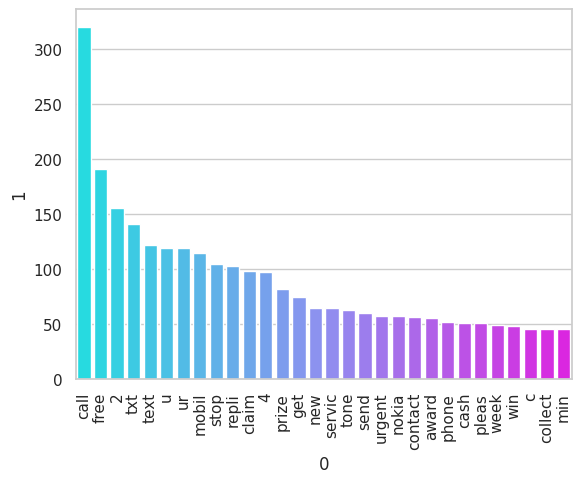

In [ ]:
sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')
plt.xticks(rotation = 90)
plt.show()

<ipython-input-67-f64cd1323289>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filter_ham_df, x=filter_ham_df[0], y=filter_ham_df[1], palette='Set2', edgecolor=".2")


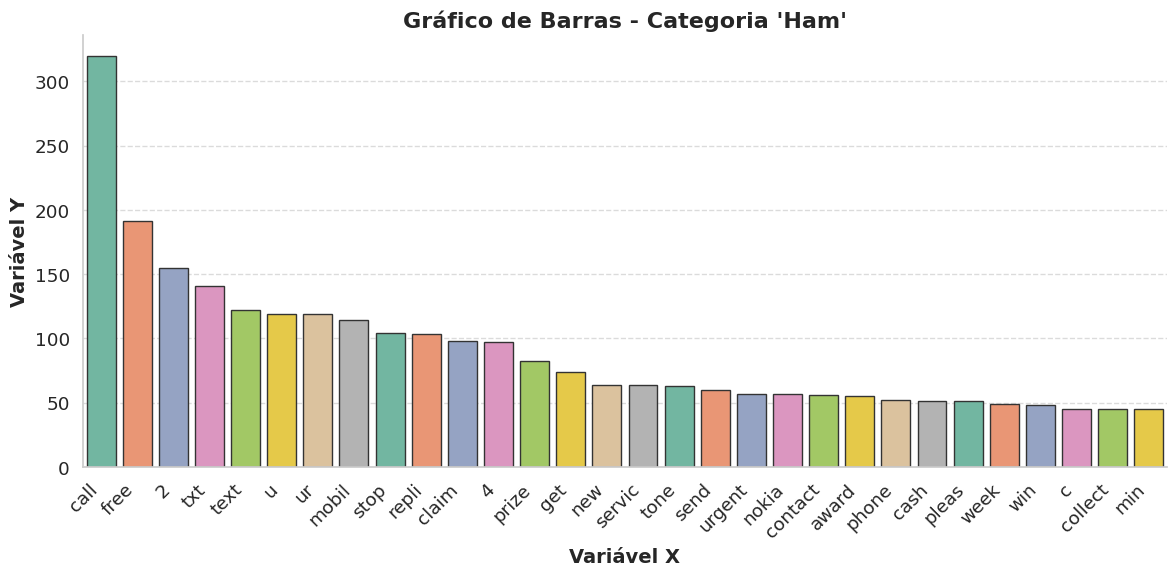

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração do estilo para uma aparência profissional
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(12, 6))

# Criar o gráfico de barras com cores suaves e bordas mais finas
sns.barplot(data=filter_ham_df, x=filter_ham_df[0], y=filter_ham_df[1], palette='Set2', edgecolor=".2")

# Adicionar rótulos e título
plt.xlabel("Variável X", fontsize=14, fontweight='bold')
plt.ylabel("Variável Y", fontsize=14, fontweight='bold')
plt.title("Gráfico de Barras - Categoria 'Ham'", fontsize=16, fontweight='bold')

# Rotacionar os rótulos no eixo x para melhor legibilidade
plt.xticks(rotation=45, ha="right")

# Ajustar o layout para evitar que os rótulos do eixo x se sobreponham
plt.tight_layout()

# Adicionar grade apenas no eixo y para uma aparência mais limpa
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remover a borda superior e direita
sns.despine()

# Mostrar o gráfico
plt.show()



# 7. Model Building

7.1 | Initializing CountVectorizer and TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfid = TfidfVectorizer(max_features = 3000)

7.2 | Dependent and Independent Variable

In [ ]:
X = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

7.3 | Split into Train and Test Data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 2)

7.4 | Import the Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

7.5 | Initialize the Models

In [ ]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb  = XGBClassifier(n_estimators = 50, random_state = 2)

7.6 | Dictionary of the Models

In [ ]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb

}

7.7 |Train the Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score
def train_classifier(clfs, X_train, y_train, X_test, y_test):
    clfs.fit(X_train,y_train)
    y_pred = clfs.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy , precision

# 8. Evaluate the Models

In [ ]:
accuracy_scores = []
precision_scores = []
for name , clfs in clfs.items():
    current_accuracy, current_precision = train_classifier(clfs, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)



For:  SVC
Accuracy:  0.9758220502901354
Precision:  0.9747899159663865

For:  KNN
Accuracy:  0.9052224371373307
Precision:  1.0

For:  NB
Accuracy:  0.9709864603481625
Precision:  1.0

For:  DT
Accuracy:  0.9274661508704062
Precision:  0.8118811881188119

For:  LR
Accuracy:  0.9584139264990329
Precision:  0.9702970297029703

For:  RF
Accuracy:  0.9758220502901354
Precision:  0.9829059829059829

For:  Adaboost
Accuracy:  0.960348162475822
Precision:  0.9292035398230089

For:  Bgc
Accuracy:  0.9584139264990329
Precision:  0.8682170542635659

For:  ETC
Accuracy:  0.9748549323017408
Precision:  0.9745762711864406

For:  GBDT
Accuracy:  0.9468085106382979
Precision:  0.9191919191919192

For:  xgb
Accuracy:  0.9671179883945842
Precision:  0.9262295081967213


<ipython-input-83-0f7172ad4016>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Classifier', data=df_results, palette='viridis')
<ipython-input-83-0f7172ad4016>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Classifier', data=df_results, palette='magma')


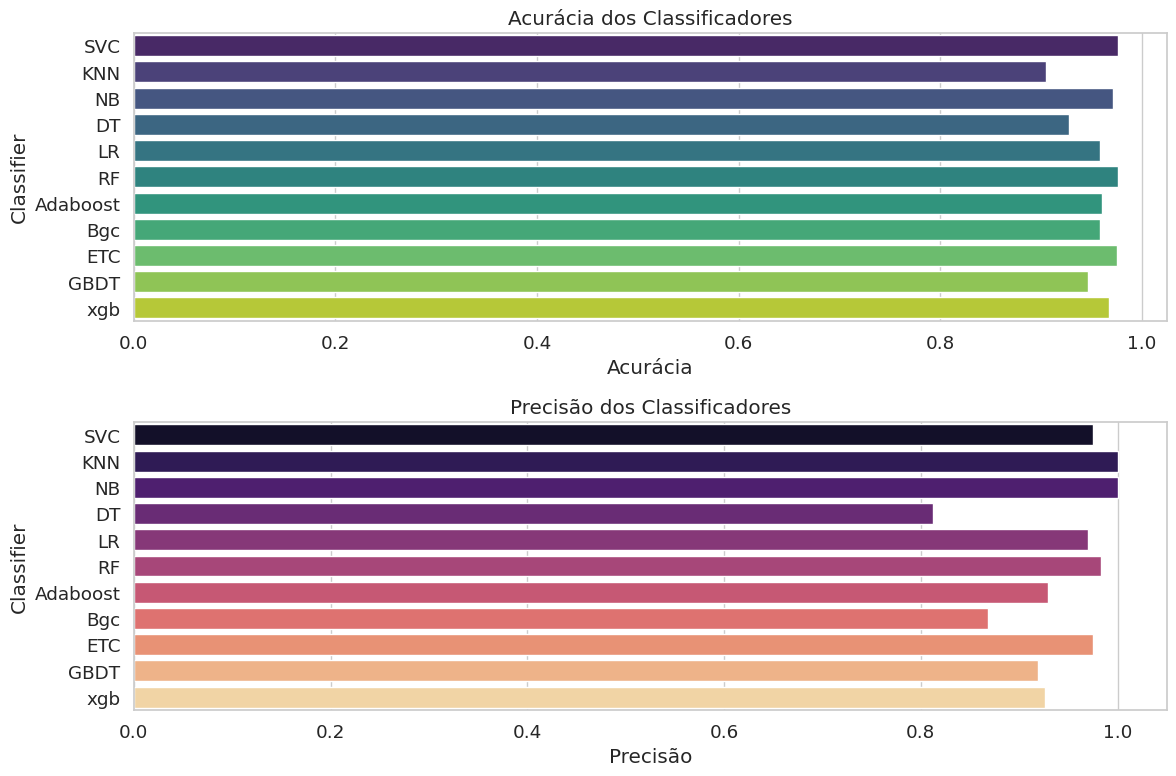

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
classifiers = ['SVC', 'KNN', 'NB', 'DT', 'LR', 'RF', 'Adaboost', 'Bgc', 'ETC', 'GBDT', 'xgb']
accuracy_scores = [0.9758220502901354, 0.9052224371373307, 0.9709864603481625, 0.9274661508704062, 0.9584139264990329, 0.9758220502901354, 0.960348162475822, 0.9584139264990329, 0.9748549323017408, 0.9468085106382979, 0.9671179883945842]
precision_scores = [0.9747899159663865, 1.0, 1.0, 0.8118811881188119, 0.9702970297029703, 0.9829059829059829, 0.9292035398230089, 0.8682170542635659, 0.9745762711864406, 0.9191919191919192, 0.9262295081967213]

# Criar DataFrame
df_results = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Configuração do estilo para uma aparência profissional
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(12, 8))

# Criar gráfico de barras horizontal para Acurácia
plt.subplot(2, 1, 1)
sns.barplot(x='Accuracy', y='Classifier', data=df_results, palette='viridis')
plt.title('Acurácia dos Classificadores')
plt.xlabel('Acurácia')

# Criar gráfico de barras horizontal para Precisão
plt.subplot(2, 1, 2)
sns.barplot(x='Precision', y='Classifier', data=df_results, palette='magma')
plt.title('Precisão dos Classificadores')
plt.xlabel('Precisão')

# Ajustar o layout para evitar sobreposições
plt.tight_layout()

# Mostrar o gráfico
plt.show()


<ipython-input-116-94b4462d9ee6>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Accuracy', x='Classifier', data=df_results, palette='viridis')
<ipython-input-116-94b4462d9ee6>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Precision', x='Classifier', data=df_results, palette='Paired')


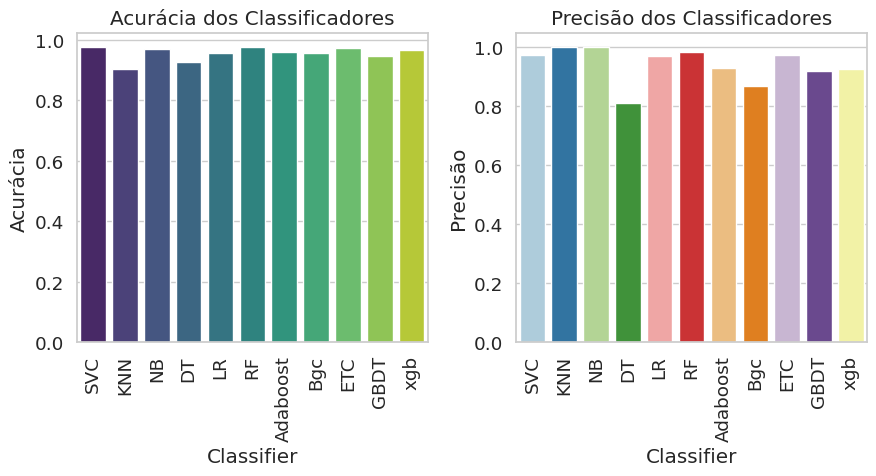

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
classifiers = ['SVC', 'KNN', 'NB', 'DT', 'LR', 'RF', 'Adaboost', 'Bgc', 'ETC', 'GBDT', 'xgb']
accuracy_scores = [0.9758220502901354, 0.9052224371373307, 0.9709864603481625, 0.9274661508704062, 0.9584139264990329, 0.9758220502901354, 0.960348162475822, 0.9584139264990329, 0.9748549323017408, 0.9468085106382979, 0.9671179883945842]
precision_scores = [0.9747899159663865, 1.0, 1.0, 0.8118811881188119, 0.9702970297029703, 0.9829059829059829, 0.9292035398230089, 0.8682170542635659, 0.9745762711864406, 0.9191919191919192, 0.9262295081967213]

# Criar DataFrame
df_results = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Configuração do estilo para uma aparência profissional
sns.set(style="whitegrid", font_scale=1.2)

# Reduzir tamanho da figura em 25%
plt.figure(figsize=(9,5))

# Criar gráfico de barras vertical para Acurácia
plt.subplot(1, 2, 1)
sns.barplot(y='Accuracy', x='Classifier', data=df_results, palette='viridis')
plt.title('Acurácia dos Classificadores')
plt.ylabel('Acurácia')
plt.xticks(rotation=90)  # Rotacionar os rótulos do eixo x

# Criar gráfico de barras vertical para Precisão
plt.subplot(1, 2, 2)
sns.barplot(y='Precision', x='Classifier', data=df_results, palette='Paired')
plt.title('Precisão dos Classificadores')
plt.ylabel('Precisão')
plt.xticks(rotation=90)  # Rotacionar os rótulos do eixo x

# Ajustar o layout para evitar sobreposições
plt.tight_layout()

# Mostrar o gráfico
plt.show()



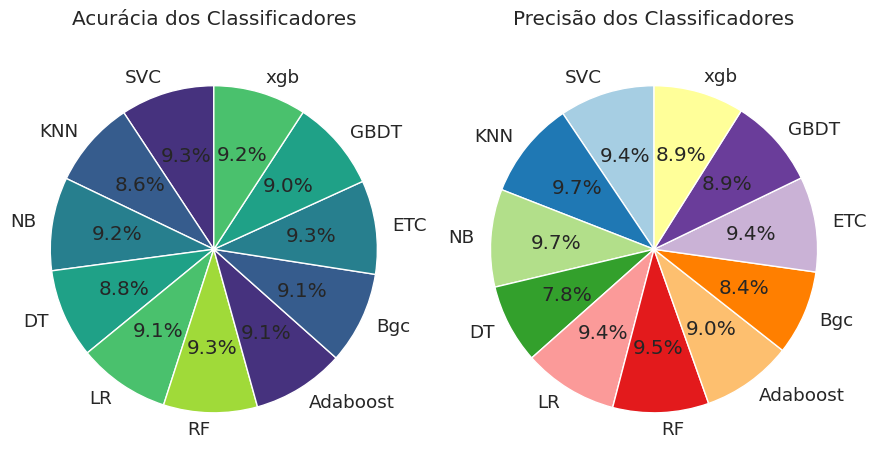

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
classifiers = ['SVC', 'KNN', 'NB', 'DT', 'LR', 'RF', 'Adaboost', 'Bgc', 'ETC', 'GBDT', 'xgb']
accuracy_scores = [0.9758220502901354, 0.9052224371373307, 0.9709864603481625, 0.9274661508704062, 0.9584139264990329, 0.9758220502901354, 0.960348162475822, 0.9584139264990329, 0.9748549323017408, 0.9468085106382979, 0.9671179883945842]
precision_scores = [0.9747899159663865, 1.0, 1.0, 0.8118811881188119, 0.9702970297029703, 0.9829059829059829, 0.9292035398230089, 0.8682170542635659, 0.9745762711864406, 0.9191919191919192, 0.9262295081967213]

# Criar DataFrame
df_results = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Configuração do estilo para uma aparência profissional
sns.set(style="whitegrid", font_scale=1.2)

# Reduzir tamanho da figura em 25%
plt.figure(figsize=(9, 5))

# Criar gráfico de pizza para Acurácia
plt.subplot(1, 2, 1)
plt.pie(df_results['Accuracy'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('viridis'), startangle=90)
plt.axis('equal')  # Assegura que o gráfico de pizza é desenhado como um círculo.
plt.title('Acurácia dos Classificadores')

# Criar gráfico de pizza para Precisão
plt.subplot(1, 2, 2)
plt.pie(df_results['Precision'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('Paired'), startangle=90)
plt.axis('equal')  # Assegura que o gráfico de pizza é desenhado como um círculo.
plt.title('Precisão dos Classificadores')

# Ajustar o layout para evitar sobreposições
plt.tight_layout()

# Mostrar o gráfico
plt.show()


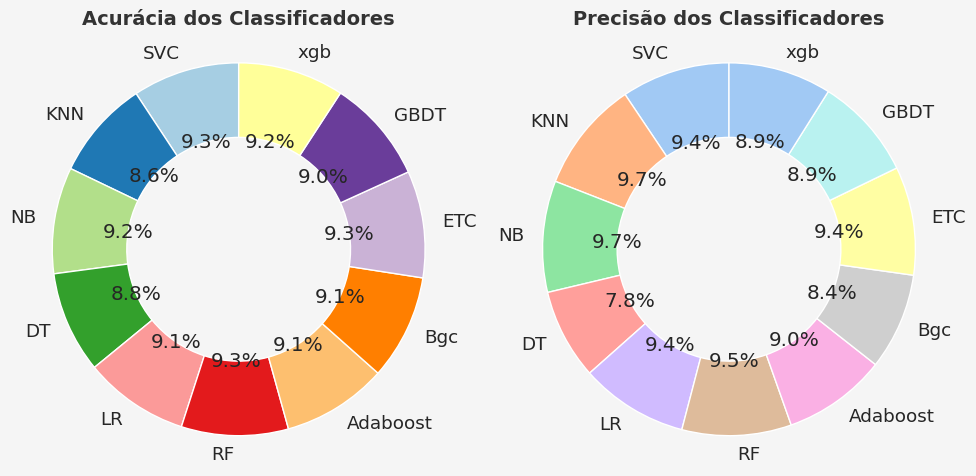

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
classifiers = ['SVC', 'KNN', 'NB', 'DT', 'LR', 'RF', 'Adaboost', 'Bgc', 'ETC', 'GBDT', 'xgb']
accuracy_scores = [0.9758220502901354, 0.9052224371373307, 0.9709864603481625, 0.9274661508704062, 0.9584139264990329, 0.9758220502901354, 0.960348162475822, 0.9584139264990329, 0.9748549323017408, 0.9468085106382979, 0.9671179883945842]
precision_scores = [0.9747899159663865, 1.0, 1.0, 0.8118811881188119, 0.9702970297029703, 0.9829059829059829, 0.9292035398230089, 0.8682170542635659, 0.9745762711864406, 0.9191919191919192, 0.9262295081967213]

# Criar DataFrame
df_results = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Configuração do estilo para uma aparência profissional e moderna
sns.set(style="whitegrid", font_scale=1.2, rc={'axes.facecolor': '#f5f5f5', 'figure.facecolor': '#f5f5f5'})

# Reduzir tamanho da figura em 25%
plt.figure(figsize=(10, 5))

# Criar gráfico de pizza para Acurácia
plt.subplot(1, 2, 1)
plt.pie(df_results['Accuracy'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('Paired'), startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.axis('equal')  # Assegura que o gráfico de pizza é desenhado como um círculo.
plt.title('Acurácia dos Classificadores', fontsize=14, fontweight='bold', color='#333333')

# Criar gráfico de pizza para Precisão
plt.subplot(1, 2, 2)
plt.pie(df_results['Precision'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.axis('equal')  # Assegura que o gráfico de pizza é desenhado como um círculo.
plt.title('Precisão dos Classificadores', fontsize=14, fontweight='bold', color='#333333')

# Ajustar o layout para evitar sobreposições
plt.tight_layout()

# Mostrar o gráfico
plt.show()


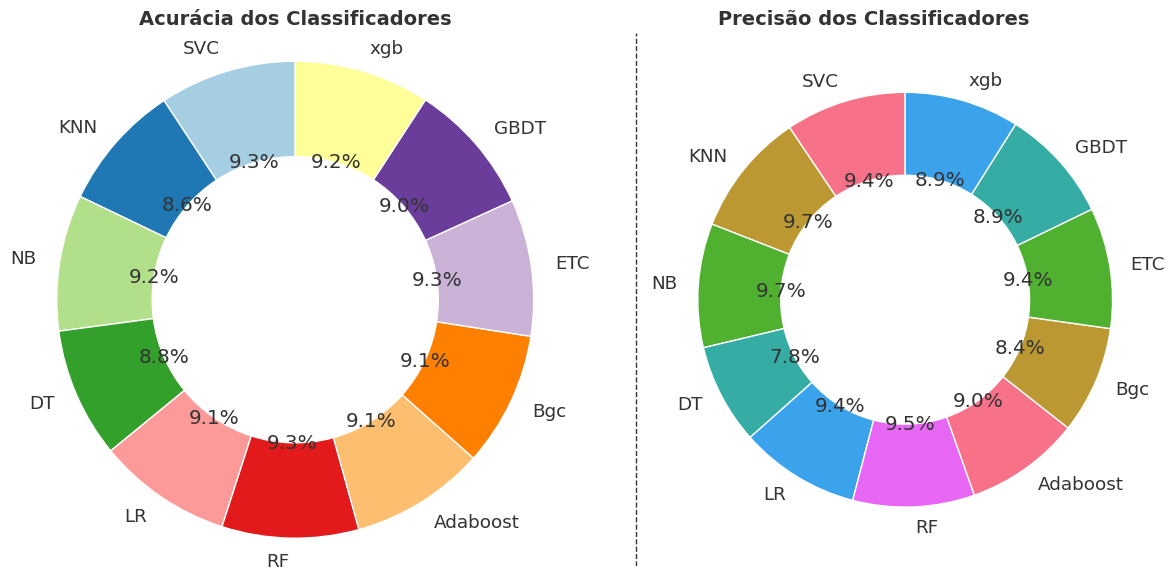

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
classifiers = ['SVC', 'KNN', 'NB', 'DT', 'LR', 'RF', 'Adaboost', 'Bgc', 'ETC', 'GBDT', 'xgb']
accuracy_scores = [0.9758220502901354, 0.9052224371373307, 0.9709864603481625, 0.9274661508704062, 0.9584139264990329, 0.9758220502901354, 0.960348162475822, 0.9584139264990329, 0.9748549323017408, 0.9468085106382979, 0.9671179883945842]
precision_scores = [0.9747899159663865, 1.0, 1.0, 0.8118811881188119, 0.9702970297029703, 0.9829059829059829, 0.9292035398230089, 0.8682170542635659, 0.9745762711864406, 0.9191919191919192, 0.9262295081967213]

# Criar DataFrame
df_results = pd.DataFrame({
    'Classifier': classifiers,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Configuração do estilo para uma aparência moderna
sns.set(style="whitegrid", font_scale=1.2, rc={'axes.facecolor': '#ffffff', 'figure.facecolor': '#ffffff'})

# Definir tamanho da figura
plt.figure(figsize=(12, 6))

# Criar gráfico de pizza para Acurácia
plt.subplot(1, 2, 1)
plt.pie(df_results['Accuracy'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('Paired'), startangle=90, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=1), textprops={'color': '#333333'})
plt.axis('equal')
plt.title('Acurácia dos Classificadores', fontsize=14, fontweight='bold', color='#333333')

# Criar gráfico de pizza para Precisão
plt.subplot(1, 2, 2)
plt.pie(df_results['Precision'], labels=df_results['Classifier'], autopct='%1.1f%%', colors=sns.color_palette('husl'), startangle=90, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=1), textprops={'color': '#333333'})
plt.axis('equal')
plt.title('Precisão dos Classificadores', fontsize=14, fontweight='bold', color='#333333')

# Adicionar linha vertical entre os gráficos
plt.axvline(x=-1.3, color='#333333', linestyle='--', linewidth=1)

# Ajustar o layout para evitar sobreposições
plt.tight_layout()

# Mostrar o gráfico
plt.show()



# 9. Conclusion


Conclusion: In our evaluation of various classification algorithms, we observed the following key insights:

Support Vector Classifier (SVC) and Random Forest (RF) demonstrated the highest accuracy, both achieving approximately 97.58%.
Naive Bayes (NB) achieved a perfect precision score, indicating zero false positives.
Other models, including Gradient Boosting, Adaboost, Logistic Regression, and Bagging Classifier, displayed competitive performance with accuracy scores ranging from 94.68% to 96.03%.

The selection of the optimal model should consider factors beyond just accuracy, such as computational efficiency and the specific requirements of the application. It is advisable to perform further model fine-tuning and validation before making a final choice. </span>